# TP2 — Validação e EDA estatística do dataset de segurança

Continuação da análise inicial do TP1. **Status: passos 1 a 8 concluídos.** Os atributos numéricos estão definidos e calculados. As visualizações e correlações estão registradas abaixo; o teste de hipótese está documentado no passo 5. Este notebook executa de forma independente a partir dos dados e scripts compartilhados do projeto.

## Objetivo e escopo da análise — TP2

### Problema do Fintech Guard

O Fintech Guard é um agente de atendimento bancário e investimentos. Seu desafio de IA é identificar indícios de fraude ou engenharia social nas mensagens recebidas. A proteção de saldos, CPF e outros dados sensíveis, incluindo prevenção de vazamento de dados pela IA, é um requisito do sistema; a EDA, isoladamente, não demonstra essa proteção.

### Objetivo da análise

Investigar características das mensagens benignas e das diferentes classes de ameaça, avaliando a qualidade dos dados e possíveis diferenças estatísticas que apoiem a futura classificação.

**Pergunta orientadora:** quais características observáveis dos textos e quais limitações do dataset devem orientar o planejamento de um classificador de mensagens benignas e ameaças de engenharia social?

### Papel dos datasets

| Dataset | Papel no projeto | Limite de interpretação |
|---|---|---|
| Multiclass NLP Dataset for Phishing and Social Engineering Threat Detection | Principal para a EDA do TP2 ligada ao desafio de segurança das mensagens. | Seus rótulos representam classes de ameaça ou conteúdo benigno; não comprovam ocorrência de fraude bancária real nem intenção do autor. |
| BANKING77 | Complementar para identificar intenções de atendimento bancário e contextualizar o domínio. | Seus rótulos são intenções de atendimento, não rótulos de fraude; uma categoria sobre segurança da conta não torna a mensagem maliciosa. |

### Continuidade em relação ao TP1

A EDA corrigida do BANKING77 permanece preservada em `notebooks/TP1/banking77/01_eda_banking77.ipynb`. A análise inicial de segurança está preservada em `notebooks/TP1/security/01_dataset_understanding.ipynb`. Este notebook registra a continuação no TP2. No TP2, este conjunto passa a ser o foco principal da análise estatística, por estar mais diretamente relacionado ao desafio de IA definido para o Fintech Guard. Os dois datasets não serão concatenados nem tratados como se compartilhassem a mesma taxonomia.

A observação do TP1 sobre mensagens longas de Phishing foi localizada e formalizada no passo 5. É uma análise exploratória, não uma hipótese anteriormente testada no TP1.

### Responsabilidade e limites desta entrega

- **Integrante A:** qualidade e tratamento dos dados, atributos exploratórios, correlações, visualizações, teste de hipótese com interpretação e relatório de EDA.
- **Integrante B:** API, autenticação, controles OWASP, rate limiting, testes de segurança e auditoria ZAP.
- **TP3:** formular a pergunta de classificação e planejar a arquitetura de IA a partir das evidências do TP2. A escolha entre classificação binária e multiclasse permanece em aberto; não haverá treinamento nesta etapa.

O dataset de segurança contém textos em inglês e não é exclusivamente bancário. A adequação ao contexto de atendimento pretendido, a representatividade e as condições de uso documentadas no TP1 precisam ser examinadas. Padrões estatísticos serão tratados como evidências exploratórias, não como prova de capacidade de detecção ou de proteção contra vazamento.

**Status:** passos 1 a 8 concluídos. A reconstrução e a limpeza foram revalidadas a partir do Excel, com auditoria por linha. Correlações são apresentadas no passo 4; o teste de hipótese está documentado no passo 5.


## Fonte e continuidade

Dataset: Multiclass NLP Dataset for Phishing and Social Engineering Threat Detection. [Fonte oficial](https://zenodo.org/records/15235123), consultada em 23/09/2026. O MD5 publicado coincide com o Excel local. A licença não está identificada no campo Rights/License consultado; as condições de uso continuam pendentes. A informação sobre anonimização é dos autores, não uma auditoria realizada neste TP.

O TP1 documenta a reconstrução inicial e suas decisões. Aqui verificamos essas decisões, seus resultados e a rastreabilidade, sem depender de executar outro notebook primeiro.

## 1. Carregamento e validação reproduzível

O validador lê o Excel e compara o resultado com os CSVs existentes. Exporta apenas os arquivos de auditoria em `reports/TP2/security_validation`; não regrava os dados.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'scripts' / 'validate_security_dataset.py').exists():
    ROOT = ROOT.parent
if not (ROOT / 'scripts' / 'validate_security_dataset.py').exists():
    raise FileNotFoundError('Execute o notebook dentro do projeto Fintech Guard.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.validate_security_dataset import validate_dataset

validacao = validate_dataset(ROOT)
df_raw = validacao['raw']
df_security = validacao['reconstructed']
df_security_clean = validacao['cleaned']
print('Validação aprovada:', validacao['summary']['checks_passed'])
print('MD5 do Excel:', validacao['summary']['raw_md5'])

Validação aprovada: True
MD5 do Excel: 7213a3ee515a713f4eee2a6948f1756e


## 2. Inspeção do Excel original

As 621 células vazias em `Labels` são parte do problema estrutural: os rótulos estão anexados ao final de `Corpus`. Nas linhas 382, 390 e 404, a mensagem está dividida entre as duas colunas. A reconstrução une os fragmentos com um espaço, separa a última tabulação e aplica `strip()` nas extremidades. A preservação posterior refere-se ao texto reconstruído.

In [2]:
print("Excel original:", df_raw.shape)
display(df_raw.dtypes.rename("tipo").to_frame())
display(df_raw.isna().sum().rename("ausentes").to_frame())
display(df_raw.describe(include="all"))
print("Linhas Excel com mensagem dividida:", (df_raw.index[df_raw["Labels"].notna()] + 2).tolist())

Excel original: (624, 2)
Linhas Excel com mensagem dividida: [382, 390, 404]


,tipo
Corpus,object
Labels,object


,ausentes
Corpus,0
Labels,621


,Corpus,Labels
count,624,3
unique,615,3
top,You have won a cash prize. Confirm your identi...,the collection centre is in . As it is legall...
freq,4,1


## 3. Dados reconstruídos

Conferência explícita de dimensões, tipos, ausentes, campos vazios e `DataFrame.describe(include="all")`.

In [3]:
print('Formato reconstruído:', df_security.shape)
display(df_security.dtypes.rename('tipo').to_frame())
display(df_security.isna().sum().rename('ausentes').to_frame())
display(df_security.describe(include='all'))
print('Textos vazios:', int(df_security.text.str.strip().eq('').sum()))
print('Categorias vazias:', int(df_security.category.str.strip().eq('').sum()))

Formato reconstruído: (624, 2)
Textos vazios: 0
Categorias vazias: 0


,tipo
text,object
category,object


,ausentes
text,0
category,0


,text,category
count,624,624
unique,609,6
top,You have won a cash prize. Confirm your identi...,NOT-Malicious General Class
freq,4,171


## 4. Duplicatas, conflitos e decisões

A comparação usa `strip().lower()` apenas como chave. Grupos com mais de um rótulo são removidos integralmente. Depois, mantém-se a primeira ocorrência de cada texto normalizado e classe. Os diagnósticos de duplicação e conflito se sobrepõem; a sequência correta é 624 − 15 − 6 = 603.

In [4]:
summary = validacao['summary']
for key in ['exact_duplicate_excess', 'rows_in_exact_duplicates',
            'rows_in_normalized_duplicates', 'conflicting_normalized_groups',
            'excluded_conflict_rows', 'excluded_duplicate_rows']:
    print(key, ':', summary[key])
display(validacao['excluded'][['excel_row', 'category', 'decision',
                                'reference_excel_row', 'labels_in_normalized_group']])

exact_duplicate_excess : 9
rows_in_exact_duplicates : 14
rows_in_normalized_duplicates : 24
conflicting_normalized_groups : 6
excluded_conflict_rows : 15
excluded_duplicate_rows : 6


,excel_row,category,decision,reference_excel_row,labels_in_normalized_group
443,445,Phishing,excluded_label_conflict,<NA>,Phishing|Pretexting
460,462,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
461,463,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
462,464,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
463,465,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
464,466,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
465,467,Pretexting,excluded_label_conflict,<NA>,Phishing|Pretexting
478,480,Pretexting,excluded_duplicate,460,Pretexting
480,482,Phishing,excluded_label_conflict,<NA>,Phishing|Pretexting
481,483,Phishing,excluded_label_conflict,<NA>,Phishing|Pretexting


## 5. Dataset tratado e distribuição das classes

In [5]:
print('Formato tratado:', df_security_clean.shape)
display(df_security_clean.dtypes.rename('tipo').to_frame())
display(df_security_clean.isna().sum().rename('ausentes').to_frame())
display(df_security_clean.describe(include='all'))
print('Duplicatas normalizadas restantes:', int(df_security_clean.text.str.strip().str.lower().duplicated().sum()))
display(validacao['counts'])

Formato tratado: (603, 2)
Duplicatas normalizadas restantes: 0


,tipo
text,object
category,object


,ausentes
text,0
category,0


,text,category
count,603,603
unique,603,6
top,"You have (1) package waiting, ready for delive...",NOT-Malicious General Class
freq,1,171


,before,excluded_conflict,excluded_duplicate,after,percent_after
category,,,,,
Baiting,80,0,0,80,13.27
Malware,78,0,1,77,12.77
NOT-Malicious General Class,171,0,0,171,28.36
Phishing,117,7,0,110,18.24
Pretexting,78,8,5,65,10.78
Scareware,100,0,0,100,16.58


## 6. Preservação e rastreabilidade

Cada linha do Excel tem uma decisão em `row_audit.csv`. Para duplicatas removidas, `reference_excel_row` indica a primeira ocorrência mantida. Grupos conflitantes não têm referência mantida. `processed_csv_row` localiza os registros retidos no CSV final. Hashes identificam o texto reconstruído, a chave normalizada e as células originais; não são uma garantia de anonimização.

In [6]:
print('Decisões registradas:', len(validacao['audit']))
print('Exclusões registradas:', len(validacao['excluded']))
print('Textos mantidos iguais aos reconstruídos:', summary['retained_texts_equal_to_reconstructed'])
display(pd.DataFrame(summary['existing_csv_comparisons']).T)
display(validacao['audit'].head(5))
assert len(validacao['audit']) == 624
assert len(validacao['excluded']) == 21
assert df_security_clean.shape == (603, 2)
assert df_security_clean.category.nunique() == 6

Decisões registradas: 624
Exclusões registradas: 21
Textos mantidos iguais aos reconstruídos: True


,equal_values_and_order,sha256
data/interim/security/phishing_nlp_dataset.csv,True,8d28b8b8f8dccf7881b4b382191d86408ec2a5201032f8...
data/processed/security/phishing_nlp_dataset.csv,True,b416c4362ef0447340770b7c73a57d5705ecc8bbeaf2ef...


,sheet,excel_row,reconstruction,category,text_sha256,normalized_text_sha256,corpus_sha256,labels_cell_sha256,outer_text_whitespace_removed,decision,reference_excel_row,labels_in_normalized_group,processed_csv_row
0,in,2,split_Corpus_last_tab,Phishing,8ebf1751e27506d179df5ce93dad03ada4a15d335d4389...,5eb4f9c3a75044bc4a855c0e32b2139576c1708cc151f3...,0f0088752ee725dfe70a3f1ee28623f89d467b09ee008c...,,False,kept,2,Phishing,2
1,in,3,split_Corpus_last_tab,Phishing,bed1869a755094abd46315fe07505ed6db614a756ac34c...,30bf911c4a43faeb446484d27487770c6d2a78d2604659...,d09101bcc0ebf19c031afb930768fdfe2142333e33aa59...,,False,kept,3,Phishing,3
2,in,4,split_Corpus_last_tab,Phishing,66c3fdfee64165f4fc172121e461ba57736d32be23f9b2...,39dd9bccdf69d463e9592270d3081403dc3e4c831667f3...,3c4870b48605405adc60d8d6b4e4c9685fe558a7a02fef...,,False,kept,4,Phishing,4
3,in,5,split_Corpus_last_tab,Phishing,9cd416f7c8113965d53a35864b79beabd6c28d9cd5f638...,428d28e3e4752093c2c020234966729707997c1c1e3f6b...,affadec87aa13710041f68524f7c02197954440f415901...,,False,kept,5,Phishing,5
4,in,6,split_Corpus_last_tab,Phishing,63f80c048e343f424036ead688980159cf3a90be41b438...,2249cc7ef460befcc16c362ae583b3e98c80f46780ce6c...,65ca188360478e86ed192aa634f58159d06775158932b2...,,False,kept,6,Phishing,6


### Resultado e limites da validação

Foram reproduzidas **603 mensagens em seis classes**, sem ausentes, textos vazios, duplicatas normalizadas ou conflitos remanescentes. Os dois CSVs existentes coincidem com a reconstrução/limpeza e são preservados.

Os nove excedentes de duplicatas exatas encontrados antes da limpeza não devem ser somados às 15 exclusões por conflito: há sobreposição entre os diagnósticos. A sequência aplicada é **624 − 15 − 6 = 603**. A auditoria registra 624 decisões, das quais 21 são exclusões.

A classe `Pretexting` passa de 78 para 65 exemplos, e `Phishing`, de 117 para 110. Excluir conflitos reduz ruído observável, mas também remove exemplos potencialmente ambíguos e pode facilitar artificialmente a futura avaliação. A ausência de conflitos exatos restantes não comprova que todos os rótulos estejam corretos.

A amostra continua pequena, em inglês e não exclusivamente bancária. A classe benigna tem 171 exemplos e a menor, `Pretexting`, 65. Isso requer cuidado com particionamento e métricas por classe. Os resultados não demonstram generalização para clientes reais. A licença segue sem esclarecimento na fonte consultada.

**Evidências:** `reports/TP2/security_validation/row_audit.csv` (todas as linhas), `excluded_rows.csv` (21 exclusões), `class_counts.csv`, dois arquivos `describe_*.csv` e `summary.json`. O README dessa pasta explica as colunas e a reprodução.

## 7. Atributos numéricos exploratórios — passo 3

As sete medidas são calculadas sobre o texto tratado preservado, antes de qualquer conversão de caixa. A extração não usa `category`, IDs ou hashes; esses campos servem apenas para agrupamento e rastreabilidade e não entram no heatmap.

| Coluna | Cálculo exato | Unidade |
|---|---|---|
| `n_chars` | `len(text)`: pontos de código Unicode, incluindo espaços, quebras, pontuação e URLs. | caracteres |
| `n_words` | Número de sequências de letras Unicode, admitindo apóstrofos internos retos ou curvos. URLs reconhecidas são removidas apenas da cópia usada na tokenização; números e underscores não são palavras; hífens separam palavras. | palavras |
| `mean_word_length` | Total de letras dos tokens acima dividido por `n_words`; apóstrofos não contam no comprimento. Sem palavras: 0. | letras/palavra |
| `digit_ratio` | Caracteres com `isdecimal()` divididos por `n_chars`, incluindo dígitos em URLs. Texto vazio: 0. | fração de 0 a 1 |
| `uppercase_ratio` | Letras com `isupper()` divididas pelo total de letras (`isalpha()`), incluindo letras em URLs. Sem letras: 0. | fração de 0 a 1 |
| `n_links` | Ocorrências, inclusive repetidas, de prefixos `http://`, `https://` ou `www.`, sem distinguir caixa, seguidos por conteúdo até espaço, `<`, `>`, aspas simples ou duplas. Prefixos não podem ser imediatamente precedidos por letra, número, underscore ou `@`. | ocorrências |
| `n_exclamations` | Contagem literal de `!`; `!!!` conta 3. O caractere de largura completa `！` não conta. | ocorrências |

Implementação única: `scripts/security_features.py` (versão 1). A regex de palavras é `[^\W\d_]+(?:['’][^\W\d_]+)*`. Trata-se de tokenização operacional, não análise linguística completa: `don't` conta uma palavra com quatro letras e `bank-account` conta duas. Não há normalização Unicode adicional; combinações de acentos podem se comportar de forma diferente.

A contagem de links é uma heurística de referências explícitas: não valida domínios, não distingue endereços legítimos de maliciosos e não detecta domínios sem prefixo, `hxxp` ou `[.]`. Endereços não são acessados. Valores zero por ausência de palavras/letras são convenções, não imputações de dados ausentes; entradas nulas são rejeitadas.

**Interpretação:** são atributos exploratórios, não indicadores comprovados de fraude. Tamanho, capitalização, números, links e pontuação também ocorrem em mensagens legítimas. Comprimentos de caracteres e palavras podem ser correlacionados por construção. As proporções usam denominadores diferentes e não são comparáveis diretamente como frequências absolutas. Não há treinamento, seleção de atributos por desempenho, normalização estatística ou codificação numérica das classes nesta etapa.


In [7]:
from scripts.security_features import FEATURES, build_features, export_features, extract_features
import numpy as np

df_features = build_features(df_security_clean, validacao['audit'])
pd.testing.assert_frame_equal(df_features[['text', 'category']], df_security_clean)
assert df_features.shape == (603, 12)
assert df_features.category.nunique() == 6
assert np.isfinite(df_features[FEATURES].to_numpy()).all()
assert df_features[FEATURES].ge(0).all().all()
assert df_features[['digit_ratio', 'uppercase_ratio']].le(1).all().all()
quality = export_features(df_features, ROOT)
print('603 registros; 7 atributos numéricos; textos, rótulos e ordem preservados.')
display(quality)
display(df_features[['excel_row', 'category'] + FEATURES].head())
display(df_features[FEATURES].describe())
print('Colunas constantes:', quality.index[quality.unique_values.le(1)].tolist())
print('Mensagens sem palavras:', int(df_features.n_words.eq(0).sum()))
print('Mensagens com links explícitos:', int(df_features.n_links.gt(0).sum()))


603 registros; 7 atributos numéricos; textos, rótulos e ordem preservados.
Colunas constantes: ['n_links']
Mensagens sem palavras: 0
Mensagens com links explícitos: 0


,dtype,missing,unique_values,zero_count
n_chars,int64,0,188,0
n_words,int64,0,77,0
mean_word_length,float64,0,329,0
digit_ratio,float64,0,50,551
uppercase_ratio,float64,0,259,0
n_links,int64,0,1,603
n_exclamations,int64,0,3,567


,excel_row,category,n_chars,n_words,mean_word_length,digit_ratio,uppercase_ratio,n_links,n_exclamations
0,2,Phishing,97,16,4.687500,0.010309,0.026667,0,0
1,3,Phishing,113,22,4.090909,0.000000,0.022222,0,0
2,4,Phishing,94,17,4.470588,0.000000,0.026316,0,0
3,5,Phishing,53,10,3.800000,0.018868,0.052632,0,0
4,6,Phishing,97,15,5.066667,0.010309,0.039474,0,0


,n_chars,n_words,mean_word_length,digit_ratio,uppercase_ratio,n_links,n_exclamations
count,603.000000,603.000000,603.000000,603.000000,603.000000,603.0,603.000000
mean,188.069652,33.008292,4.721194,0.001235,0.033652,0.0,0.064677
std,400.928435,70.727766,0.580592,0.006368,0.061838,0.0,0.265633
min,10.000000,3.000000,2.000000,0.000000,0.001337,0.0,0.000000
25%,84.000000,14.000000,4.314145,0.000000,0.017094,0.0,0.000000
50%,101.000000,17.000000,4.692308,0.000000,0.026667,0.0,0.000000
75%,134.500000,25.000000,5.129167,0.000000,0.036364,0.0,0.000000
max,3693.000000,635.000000,6.615385,0.093750,1.000000,0.0,2.000000


### Exemplo verificável

Em `ABC def 12!!`, são 12 caracteres, duas palavras, três letras por palavra, 2/12 de dígitos, 3/6 de maiúsculas, nenhum link e duas exclamações.

In [8]:
display(pd.DataFrame([extract_features('ABC def 12!!')], index=['Exemplo sintético']))

,n_chars,n_words,mean_word_length,digit_ratio,uppercase_ratio,n_links,n_exclamations
Exemplo sintético,12,2,3.0,0.166667,0.5,0,2


### Resultados do passo 3

Foram calculados sete atributos para as 603 mensagens, sem valores ausentes ou infinitos. Textos, rótulos, ordem e seis classes foram preservados. A mediana é 101 caracteres e 17 palavras; as médias são aproximadamente 188,07 e 33,01, respectivamente. O máximo de 3.693 caracteres mostra que mensagens longas podem influenciar médias e correlações; não houve corte ou exclusão por tamanho.

Há 52 mensagens com dígitos e 36 com exclamações. Nenhuma contém links reconhecidos pela regra explícita adotada: `n_links` tem 603 zeros e é constante. Isso não prova ausência de referências externas, pois domínios nus e ofuscados não são reconhecidos. A coluna foi preservada nas evidências, mas excluída do heatmap: correlação com uma variável de variância zero é indefinida, não zero.

Seis testes automatizados verificam exemplos calculados manualmente, texto vazio/sem letras, apóstrofos e hífens, URLs, Unicode e rejeição de entradas inválidas. Reprodução: `python -m unittest discover -s tests -p test_security_features.py -v`.

Esses resultados descrevem a amostra inteira; não demonstram associação com uma classe, causalidade ou capacidade de detectar fraude. O passo 4 abaixo apresenta as visualizações; o teste de hipótese está documentado no passo 5.


## 8. Visualizações — passo 4

Somente os atributos listados em `FEATURES` entram na correlação. Classe, linha do Excel, linha do CSV e hash ficam de fora. A categoria é usada apenas como agrupamento visual, sem códigos numéricos arbitrários. Mantemos todos os 603 registros, inclusive extremos, sem balanceamento. As figuras são salvas em `reports/TP2/figures` e incorporadas às saídas deste notebook.

Pearson descreve associação linear; Spearman descreve associação monotônica por postos, reduzindo a influência da magnitude dos extremos. São medidas descritivas desta amostra, sem interpretação causal ou teste formal de significância nesta etapa.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
FIGURES = ROOT / 'reports/TP2/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
class_order = sorted(df_features.category.unique())
palette = dict(zip(class_order, sns.color_palette('colorblind', len(class_order))))
labels = {'n_chars': 'Caracteres', 'n_words': 'Palavras',
          'mean_word_length': 'Média de letras/palavra', 'digit_ratio': 'Proporção de dígitos',
          'uppercase_ratio': 'Proporção de maiúsculas', 'n_links': 'Links',
          'n_exclamations': 'Exclamações'}
active_features = [f for f in FEATURES if df_features[f].nunique() > 1]
constant_features = [f for f in FEATURES if f not in active_features]
print('Excluídos da correlação por variância zero:', constant_features)
pearson = df_features[active_features].corr(method='pearson')
# Spearman = Pearson dos postos médios; não exige instalar SciPy antes do passo 5.
spearman = df_features[active_features].rank(method='average').corr(method='pearson')
pearson.to_csv(FIGURES / 'correlation_pearson.csv', index_label='feature')
spearman.to_csv(FIGURES / 'correlation_spearman.csv', index_label='feature')
def save_figure(fig, filename):
    fig.savefig(FIGURES / filename, dpi=160, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)


Excluídos da correlação por variância zero: ['n_links']


### 8.1 Heatmap de correlação com seaborn

Caracteres × palavras: Pearson = 0.9986 ; Spearman = 0.958


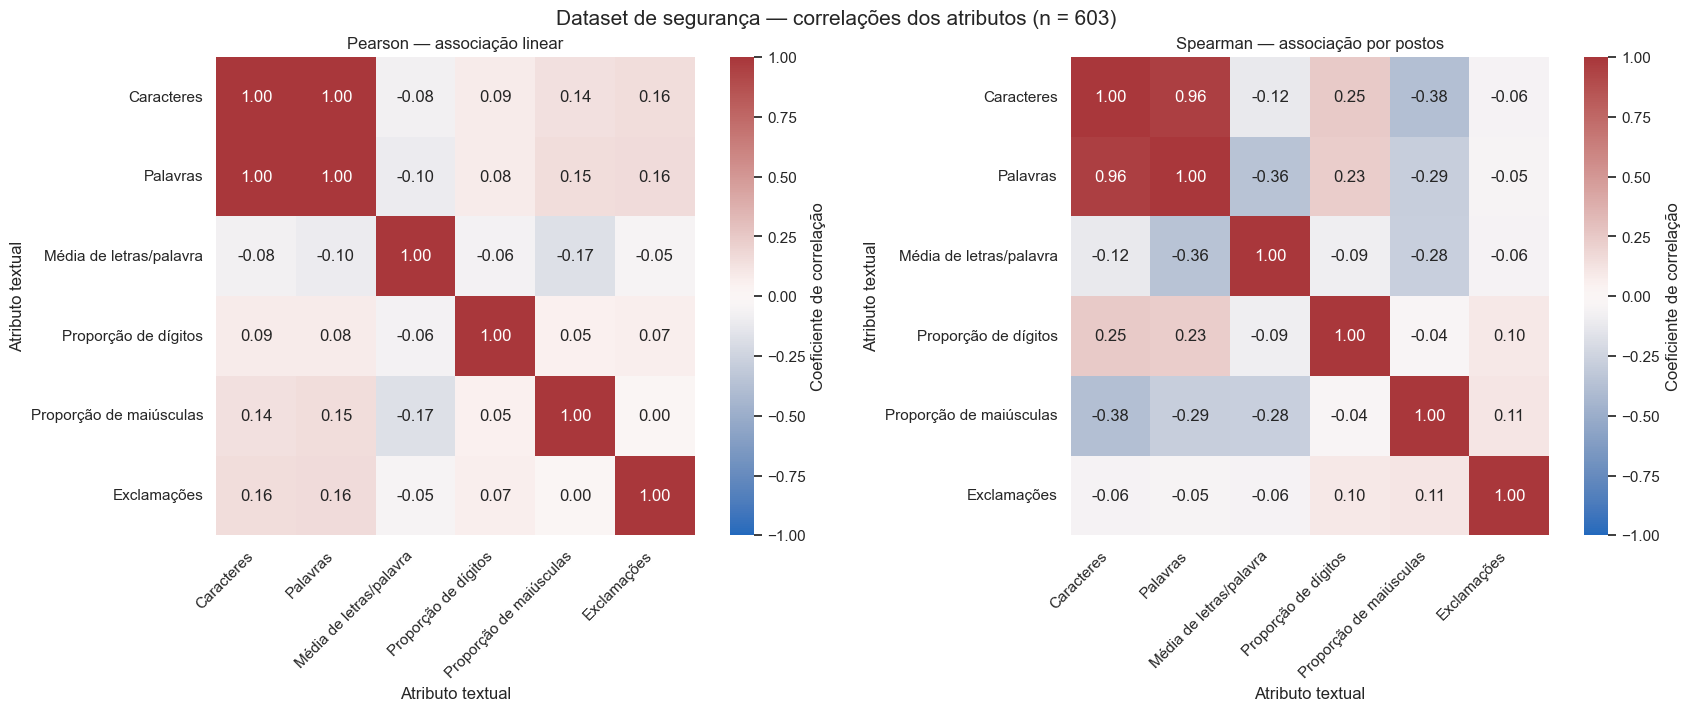

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7), layout='constrained')
for ax, matrix, title in zip(axes, [pearson, spearman], ['Pearson — associação linear', 'Spearman — associação por postos']):
    sns.heatmap(matrix.rename(index=labels, columns=labels), ax=ax,
                annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, center=0,
                square=True, cbar_kws={'label': 'Coeficiente de correlação'})
    ax.set_title(title)
    ax.set_xlabel('Atributo textual')
    ax.set_ylabel('Atributo textual')
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels(): tick.set_horizontalalignment('right')
fig.suptitle('Dataset de segurança — correlações dos atributos (n = 603)', fontsize=15)
save_figure(fig, '01_heatmap_correlations.png')
print('Caracteres × palavras:', 'Pearson =', round(pearson.loc['n_chars', 'n_words'], 4),
      '; Spearman =', round(spearman.loc['n_chars', 'n_words'], 4))


**Interpretação:** caracteres e palavras medem aspectos próximos do comprimento; sua associação positiva elevada pode refletir redundância entre medidas, não um sinal de fraude. Diferenças entre os painéis mostram que associação linear e ordenação dos valores não são equivalentes, especialmente com extremos e muitos zeros. `n_links` foi excluído por variância zero: sua correlação seria indefinida, não zero. Nenhum coeficiente mede relação com a classe, pois rótulos não entram nas matrizes. A diagonal igual a 1 é a correlação de cada atributo consigo mesmo. Neste dataset, caracteres × palavras têm Pearson = 0.9986 e Spearman = 0.9580; o valor 1,00 no heatmap de Pearson resulta do arredondamento, não de identidade perfeita.

### 8.2 Scatter plot — palavras × caracteres

Limites P95: 74.89999999999998 palavras; 387.7999999999995 caracteres


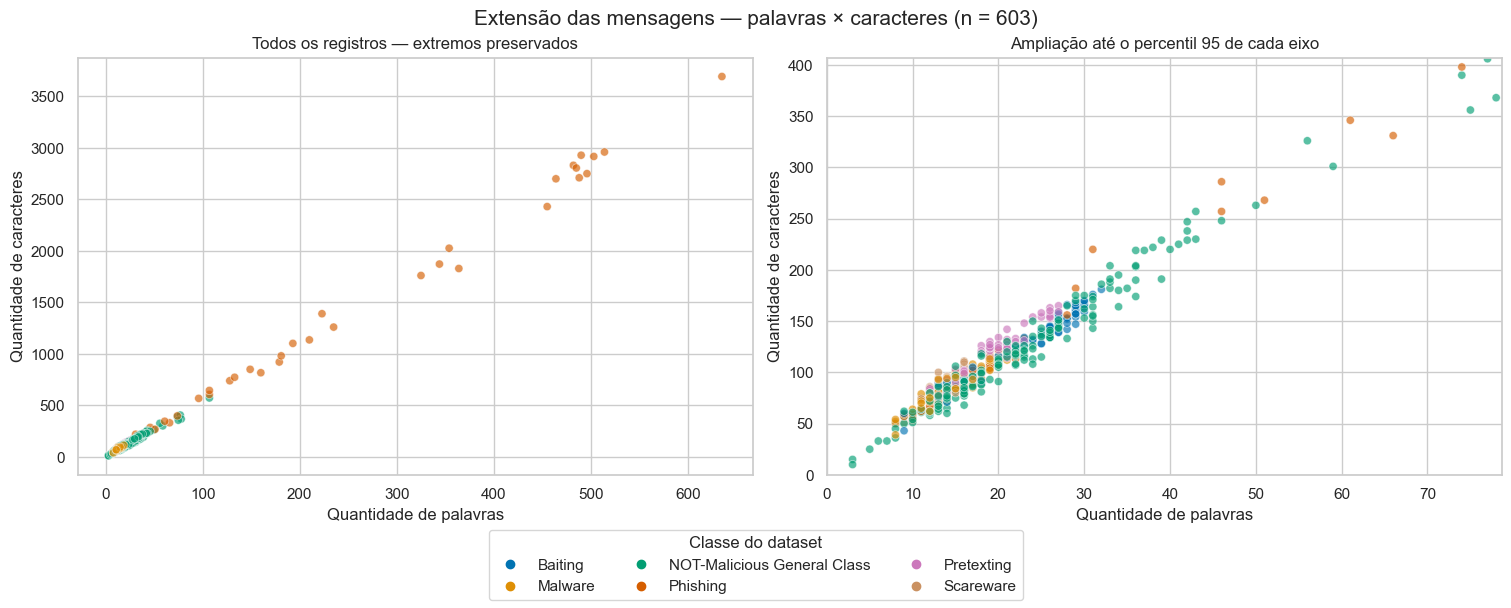

,excel_row,category,n_words,n_chars
388,390,Phishing,635,3693
387,389,Phishing,514,2960
385,387,Phishing,490,2929
386,388,Phishing,503,2917
389,391,Phishing,482,2831


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
for ax in axes:
    sns.scatterplot(data=df_features, x='n_words', y='n_chars', hue='category',
                    hue_order=class_order, palette=palette, alpha=.65, s=35,
                    ax=ax, legend=False)
    ax.set_xlabel('Quantidade de palavras')
    ax.set_ylabel('Quantidade de caracteres')
axes[0].set_title('Todos os registros — extremos preservados')
axes[1].set_title('Ampliação até o percentil 95 de cada eixo')
x95, y95 = df_features.n_words.quantile(.95), df_features.n_chars.quantile(.95)
axes[1].set_xlim(0, x95 * 1.05)
axes[1].set_ylim(0, y95 * 1.05)
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker='o', linestyle='', color=palette[c], label=c) for c in class_order]
fig.legend(handles=handles, title='Classe do dataset', loc='outside lower center', ncol=3)
fig.suptitle('Extensão das mensagens — palavras × caracteres (n = 603)', fontsize=15)
save_figure(fig, '02_scatter_words_characters.png')
display(df_features.nlargest(5, 'n_chars')[['excel_row', 'category', 'n_words', 'n_chars']])
print('Limites P95:', x95, 'palavras;', y95, 'caracteres')


**Interpretação:** mensagens com mais palavras tendem a ter mais caracteres. A visão completa evidencia casos muito longos, enquanto a ampliação permite inspecionar a concentração de mensagens curtas e a sobreposição visual entre classes. O painel ampliado limita apenas a janela exibida: os pontos fora dela continuam na base e no painel completo. A tabela identifica os cinco textos mais longos pela linha de origem, sem reproduzir o conteúdo. Comprimento isolado não demonstra separação confiável entre classes; os extremos devem ser examinados, não removidos automaticamente.

### 8.3 Comprimento × links — gráfico não produzido

`n_links` é zero em todas as 603 mensagens. Um scatter produziria apenas pontos alinhados no zero, sem variação para investigar associação. Por isso, este gráfico condicional foi omitido. A ausência de links reconhecidos não equivale à ausência de endereços ofuscados, domínios sem prefixo ou conteúdo malicioso. A coluna e sua definição continuam preservadas nas evidências do passo 3.

### 8.4 Boxplots — comprimento por classe

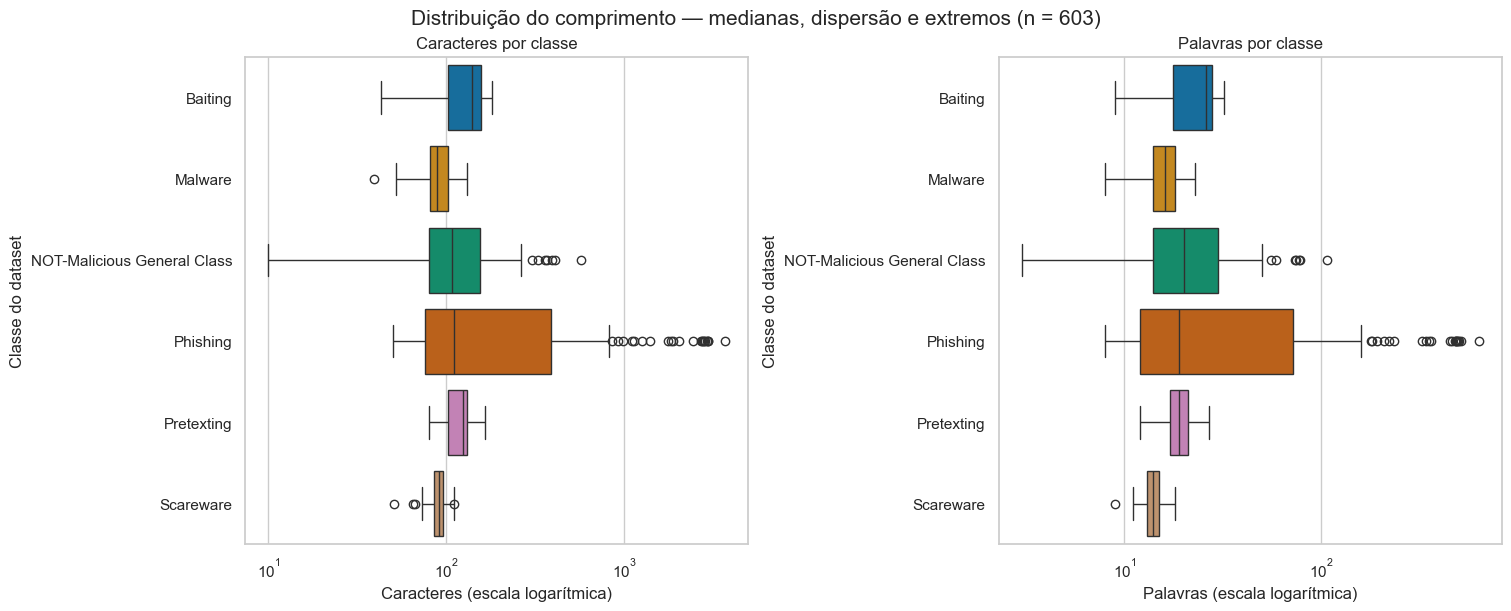

n_chars                  n_words                
                              count median min   max   count median min  max
category                                                                    
Baiting                          80  140.0  43   181      80   26.0   9   32
Malware                          77   89.0  39   130      77   16.0   8   23
NOT-Malicious General Class     171  108.0  10   572     171   20.0   3  107
Phishing                        110  111.0  50  3693     110   19.0   8  635
Pretexting                       65  124.0  80   165      65   19.0  12   27
Scareware                       100   91.0  51   111     100   14.0   9   18

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), layout='constrained')
for ax, feature in zip(axes, ['n_chars', 'n_words']):
    sns.boxplot(data=df_features, x=feature, y='category', order=class_order,
                hue='category', hue_order=class_order, palette=palette,
                legend=False, showfliers=True, ax=ax)
    ax.set_xscale('log')
    ax.set_xlabel(labels[feature] + ' (escala logarítmica)')
    ax.set_ylabel('Classe do dataset')
    ax.set_title(labels[feature] + ' por classe')
fig.suptitle('Distribuição do comprimento — medianas, dispersão e extremos (n = 603)', fontsize=15)
save_figure(fig, '03_boxplots_length_by_class.png')
display(df_features.groupby('category')[['n_chars', 'n_words']].agg(['count', 'median', 'min', 'max']))


**Interpretação e legenda:** a linha interna é a mediana; a caixa vai do primeiro ao terceiro quartil; os bigodes alcançam os valores dentro de 1,5 vezes a amplitude interquartil e os pontos além deles são extremos segundo essa regra. Todos permanecem na análise. O eixo logarítmico acomoda a grande amplitude: distâncias iguais representam razões, não diferenças absolutas. As caixas são calculadas nos valores originais e depois exibidas nessa escala. Diferenças entre medianas e dispersões motivam investigação estatística, mas o gráfico não estabelece significância nem desempenho de classificação. As classes estão identificadas diretamente no eixo vertical. Nesta amostra, Phishing apresenta a maior dispersão e concentra os textos mais longos, mas suas caixas se sobrepõem às de outras classes. Isso não permite concluir que toda mensagem longa seja maliciosa.

### 8.5 Distribuição das classes após a limpeza

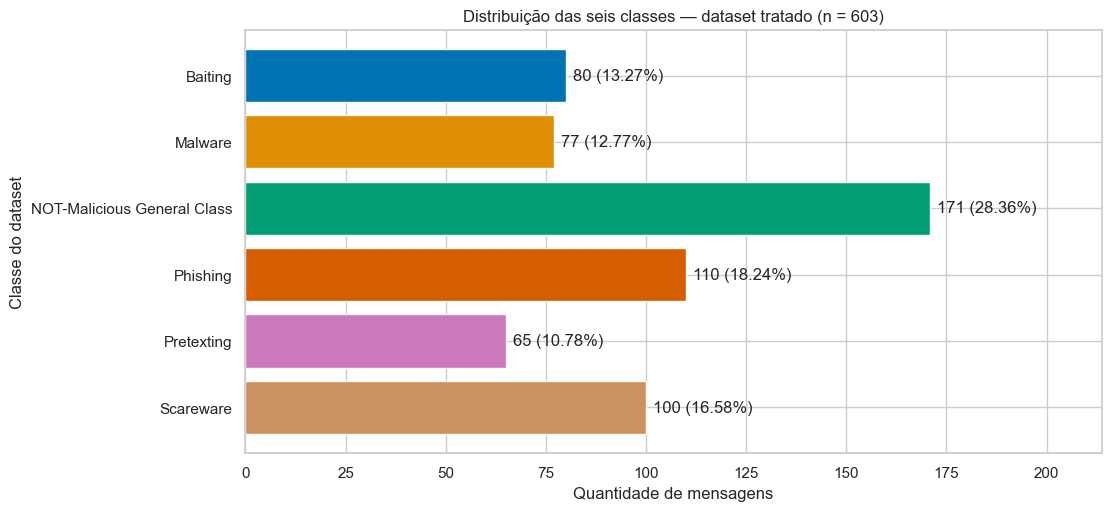

In [13]:
counts = df_features.category.value_counts().reindex(class_order)
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
bars = ax.barh(counts.index, counts.values, color=[palette[c] for c in counts.index])
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.25)
ax.bar_label(bars, labels=[f'{n} ({100*n/len(df_features):.2f}%)' for n in counts], padding=5)
ax.set_title('Distribuição das seis classes — dataset tratado (n = 603)')
ax.set_xlabel('Quantidade de mensagens')
ax.set_ylabel('Classe do dataset')
save_figure(fig, '04_class_distribution.png')


**Interpretação:** a classe benigna tem 171 mensagens (28,36%) e Pretexting, a menor, 65 (10,78%); a razão entre elas é aproximadamente 2,63. As barras representam contagens, e os rótulos mostram contagem e percentual do total. Essas proporções descrevem o dataset após a limpeza, não a prevalência de ameaças no atendimento bancário. O desbalanceamento deve orientar a divisão estratificada e a avaliação por classe no planejamento do TP3; nesta etapa não houve reamostragem.

### 8.6 Scatter plot — caracteres × proporção de maiúsculas

Caracteres × maiúsculas: Pearson = 0.1386 ; Spearman = -0.3774


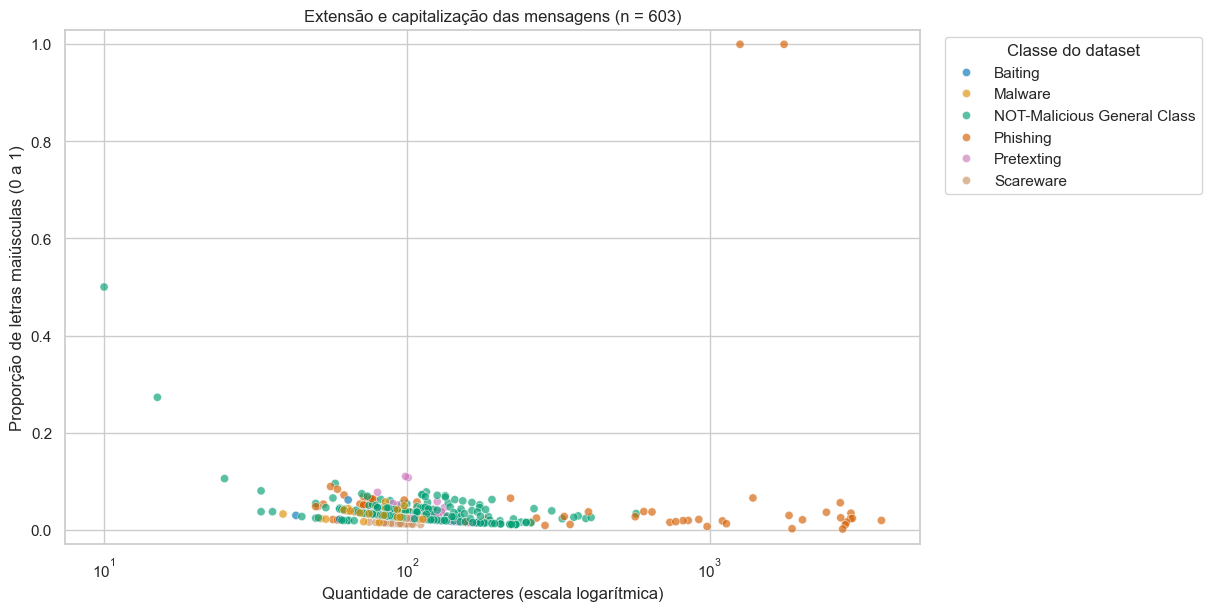

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), layout='constrained')
sns.scatterplot(data=df_features, x='n_chars', y='uppercase_ratio',
                hue='category', hue_order=class_order, palette=palette,
                alpha=.65, s=35, ax=ax)
ax.set_xscale('log')
ax.set_ylim(-.03, 1.03)
ax.set_xlabel('Quantidade de caracteres (escala logarítmica)')
ax.set_ylabel('Proporção de letras maiúsculas (0 a 1)')
ax.set_title('Extensão e capitalização das mensagens (n = 603)')
ax.legend(title='Classe do dataset', loc='upper left', bbox_to_anchor=(1.02, 1))
save_figure(fig, '05_scatter_characters_uppercase.png')
print('Caracteres × maiúsculas: Pearson =', round(pearson.loc['n_chars', 'uppercase_ratio'], 4),
      '; Spearman =', round(spearman.loc['n_chars', 'uppercase_ratio'], 4))


**Interpretação:** este segundo relacionamento compara extensão e capitalização. A proporção de maiúsculas varia entre as mensagens e as classes se sobrepõem visualmente; ela não oferece, por si só, uma fronteira de detecção. O eixo de caracteres está em escala logarítmica apenas para exibição, sem excluir os textos longos ou transformar os valores usados nas correlações. Pearson indica associação positiva fraca (aproximadamente 0,14), enquanto Spearman indica associação negativa por postos (aproximadamente -0,38). Essa diferença reforça a necessidade de examinar a forma da relação e os extremos. A proporção divide maiúsculas pelo total de letras: uma inicial maiúscula pode representar uma fração maior em textos curtos. Portanto, parte do padrão pode decorrer da construção da medida, não de um comportamento de fraude. Não foi feito novo teste de hipótese nem seleção de atributo por desempenho.

## 9. Hipótese formal — passo 5

### Origem no TP1 e natureza exploratória

O notebook `notebooks/TP1/security/01_dataset_understanding.ipynb`, seção **7. Comprimento das mensagens**, célula Markdown 29 (contagem a partir de 1), registra: “As mensagens mais longas pertencem a `Phishing`”. A mesma interpretação descreve assimetria à direita e recomenda preservar os textos longos. Era uma observação descritiva do conjunto reconstruído de 624 registros, não uma hipótese formal testada. No TP2, a comparação é formalizada sobre os 603 registros tratados.

O protocolo em `reports/TP2/hypothesis_test/protocol.json` foi salvo antes do primeiro cálculo de U e p, com data e hashes da fonte e dos dados. Isso **não é pré-registro confirmatório**: os mesmos dados já foram explorados no TP1 e nos passos 2–4. O resultado é exploratório e exige confirmação em dados independentes.

### Protocolo definido antes do cálculo

- **H₀:** as distribuições de comprimento em caracteres de Phishing e mensagens benignas são iguais.
- **H₁:** as distribuições diferem; alternativa bilateral.
- **Variável:** `n_chars = len(text)`, conforme a definição do passo 3. Sem logaritmo no teste.
- **Grupos:** X = todos os 110 registros `Phishing`; Y = todos os 171 registros `NOT-Malicious General Class`. As outras quatro classes não entram. Aplicam-se somente as exclusões já documentadas no passo 2; nenhum extremo é retirado.
- **Significância:** α = 0,05. Um único teste planejado; p < α implica rejeitar H₀. Caso contrário, não rejeitar H₀. Não serão tentadas novas comparações para obter significância.
- **Teste:** `scipy.stats.mannwhitneyu`, `alternative='two-sided'`, `method='asymptotic'`, `use_continuity=True`, `nan_policy='raise'`. A aproximação assintótica incorpora correção de empates e continuidade; o método exato não é escolhido porque há comprimentos repetidos e grupos de tamanho suficiente para a aproximação.
- **Justificativa:** comprimentos assimétricos, com extremos, e dois grupos não pareados favorecem uma comparação por postos sem exigir normalidade dos comprimentos. A escolha não depende de um teste de normalidade nem do p-valor obtido.
- **Efeito:** A = U de Phishing / (110 × 171), proporção de pares em que Phishing é mais longo com meio peso para empates. Correlação bisserial por postos `r_rb = 2*A − 1`, entre −1 e 1; sinal positivo indica tendência a comprimentos maiores em Phishing. Não é acurácia de um classificador nem probabilidade de fraude.

### Premissas e alcance

Pressupõem-se observações independentes dentro e entre grupos, comprimentos comparáveis e rótulos adequados. A deduplicação exata não garante independência: não temos IDs de autor, campanha ou família de templates. A amostra não é comprovadamente aleatória ou representativa. Essas limitações restringem a inferência para mensagens reais.

Mann–Whitney investiga ordenação relativa; não tem sensibilidade garantida a toda diferença possível de formato. Com dispersões diferentes, não será interpretado como teste exclusivo de medianas. Não rejeitar H₀ não prova distribuições iguais. Um p-valor pequeno indica incompatibilidade com H₀ sob as premissas; não informa a probabilidade de H₀ ser verdadeira.

Referência metodológica: [documentação oficial do SciPy — Mann–Whitney](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).


In [15]:
import json
from scripts.security_hypothesis import run_hypothesis

protocol = json.loads((ROOT / 'reports/TP2/hypothesis_test/protocol.json').read_text(encoding='utf-8'))
print('Protocolo registrado em:', protocol['registered_at_utc'])
print('H0:', protocol['h0'])
print('H1:', protocol['h1'])
print('Alpha:', protocol['alpha'], '| alternativa:', protocol['alternative'])
group_summary, hypothesis_result = run_hypothesis(df_features, ROOT)
display(group_summary)
display(pd.DataFrame([hypothesis_result])[['n_x', 'n_y', 'u_x', 'p_value',
                                         'common_language_A', 'rank_biserial', 'reject_h0']])
print('Conferência independente por todos os pares:', hypothesis_result['independent_pairwise_check_passed'])
print('SciPy:', hypothesis_result['scipy_version'])


Protocolo registrado em: 2026-09-23T20:15:11.468513+00:00
H0: As distribuições de comprimento em caracteres de Phishing e mensagens benignas são iguais.
H1: As distribuições de comprimento em caracteres diferem.
Alpha: 0.05 | alternativa: two-sided
Conferência independente por todos os pares: True
SciPy: 1.18.1


,n,median,q1,q3,iqr,min,max,mean,sd_sample
category,,,,,,,,,
Phishing,110,111.0,76.0,385.0,309.0,50,3693,518.990909,860.536567
NOT-Malicious General Class,171,108.0,79.5,155.5,76.0,10,572,128.175439,77.158993


,n_x,n_y,u_x,p_value,common_language_A,rank_biserial,reject_h0
0,110,171,10274.5,0.191171,0.546225,0.092451,False


### Resultado e interpretação do teste

| Grupo | n | Mediana (caracteres) | Q1 | Q3 | IQR | Mínimo | Máximo |
|---|---:|---:|---:|---:|---:|---:|---:|
| Phishing | 110 | 111 | 76 | 385 | 309 | 50 | 3.693 |
| Benignas | 171 | 108 | 79,5 | 155,5 | 76 | 10 | 572 |

Quartis calculados por interpolação linear; IQR = Q3 − Q1. As médias são 518,99 e 128,18 caracteres e os desvios-padrão amostrais, 860,54 e 77,16, respectivamente. Os extremos elevam especialmente a média de Phishing; por isso, média e mediana contam aspectos diferentes da distribuição.

**Mann–Whitney bilateral:** U de Phishing = **10.274,5**, p = **0,1911706933**, α = **0,05**. Portanto, **não rejeitamos H₀**. Não há evidência suficiente, por este teste e sob suas premissas, para concluir diferença na ordenação dos comprimentos entre os grupos. Isso não prova que as distribuições sejam iguais nem que a diferença observada na cauda seja irrelevante: o teste não detecta necessariamente toda diferença de forma ou dispersão.

**Tamanho de efeito:** A = **0,5462** e correlação bisserial por postos = **0,0925**. Entre os 18.810 pares possíveis, Phishing é mais longo em 10.222, há 105 empates e é mais curto em 8.483. Incluindo meio peso para empates, a proporção favorável a Phishing é **54,62%**, próxima do ponto neutro de 50%; o efeito por postos é próximo de zero. Essa descrição não é uma acurácia avaliada nem a probabilidade de uma mensagem ser fraudulenta.

O p-valor indica a probabilidade aproximada, sob H₀ e as premissas, de uma estatística tão ou mais extrema que a observada. **Não é a probabilidade de H₀ estar correta.** Se fosse pequeno, forneceria evidência contra H₀; mesmo assim não demonstraria que comprimento identifica fraude. Neste caso, p excede o limiar definido antes do cálculo.

### Relação com o TP1 e implicações para o TP3

A observação do TP1 sobre mensagens muito longas em Phishing permanece válida descritivamente. Entretanto, ela não implica que uma mensagem de Phishing típica seja muito mais longa: as medianas são 111 e 108 e há ampla sobreposição. A dispersão de Phishing é maior, mas esta análise não realizou um teste específico de dispersão. Não alteramos a alternativa, removemos extremos ou procuramos outro teste após conhecer p.

Para o TP3, comprimento pode continuar como atributo candidato, cuja utilidade terá de ser avaliada com outros sinais textuais e dados de teste independentes. Não se justifica criar uma regra “mensagem longa = fraude”. A exploração prévia, o tamanho e a seleção da amostra, a ambiguidade dos rótulos e a independência não comprovada limitam a generalização. Uma futura investigação da cauda deverá ser identificada como nova análise e validada separadamente, não como resgate deste resultado.

**Verificação:** U e a orientação do efeito foram conferidos pela contagem de todos os pares, com meio peso para empates. O p-valor foi conferido independentemente pela aproximação normal com correção de empates e continuidade. O notebook utiliza SciPy 1.18.1; resultados e versões estão em `reports/TP2/hypothesis_test/result.json`.


## 10. Síntese dos resultados — passo 6

Atualizada em 26/09/2026, a partir dos resultados já executados.

### Quais classes têm mais e menos exemplos?

Após a limpeza, temos **603 mensagens em seis classes**. A classe benigna (`NOT-Malicious General Class`) é a maior, com **171 exemplos (28,36%)**. Em seguida vêm Phishing, com 110; Scareware, com 100; Baiting, com 80; Malware, com 77; e Pretexting, a menor, com **65 (10,78%)**. A maior classe tem cerca de 2,63 vezes o tamanho da menor. Por isso, uma avaliação futura deve mostrar os resultados de cada classe: uma medida global pode esconder dificuldades nas classes menores. Essas proporções pertencem ao dataset e não representam a frequência de fraude no atendimento real.

### Existem diferenças relevantes entre mensagens benignas e ameaças?

Há diferenças descritivas que merecem atenção, principalmente na dispersão dos comprimentos. Na comparação realizada, Phishing tem mediana de **111 caracteres**, próxima dos **108** das mensagens benignas. Entretanto, os 50% centrais dos comprimentos de Phishing estão entre **76 e 385 caracteres**; nas benignas, entre **79,5 e 155,5**. Isso mostra maior variação no grupo Phishing, não uma separação clara entre os grupos.

O teste de Mann–Whitney retornou **p = 0,1912**, acima do nível de 5% definido antes do cálculo. Portanto, **não rejeitamos H₀**: esse teste não forneceu evidência suficiente para concluir diferença na ordenação dos comprimentos. Isso não prova que as distribuições sejam iguais e não elimina a diferença descritiva de dispersão. O efeito por postos foi **0,0925**, próximo de zero, coerente com ampla sobreposição.

O teste abrangeu **somente Phishing e mensagens benignas**. Não testamos todas as ameaças juntas, todas as combinações de classes ou diferenças de dispersão. Não podemos estender esse resultado às outras quatro classes nem concluir que os atributos detectam fraude. Um resultado sem significância é uma conclusão válida da análise; não foi substituído por outra comparação para buscar um p-valor menor.

### Os atributos parecem redundantes?

**Quantidade de caracteres e quantidade de palavras carregam informação muito semelhante**: a correlação foi 0,9986 por Pearson e 0,9580 por Spearman. Em termos simples, as mensagens com mais palavras quase sempre também têm mais caracteres. Usar ambos não significa necessariamente acrescentar duas informações independentes. A decisão de manter um ou os dois dependerá da avaliação futura do modelo, sem eliminar atributos apenas por esta exploração.

Os demais pares não apresentam correlações tão próximas de 1, mas isso não comprova independência ou utilidade preditiva. A contagem de links é um caso diferente: ficou em zero em todas as mensagens pela regra adotada. Portanto, não ajuda a diferenciar registros nesta base e foi excluída do heatmap por falta de variação. Isso não demonstra ausência de endereços ofuscados ou sem os prefixos reconhecidos.

### Há mensagens longas que exigirão atenção no processamento?

Sim. O conjunto tem mediana de **101 caracteres e 17 palavras**, mas alcança **3.693 caracteres e 635 palavras** nas respectivas medidas máximas. Os textos mais longos aparecem em Phishing, conforme já observado no TP1. Eles foram preservados: comprimento elevado não é, por si só, erro de coleta nem razão suficiente para exclusão.

No planejamento do processamento, será necessário verificar como o método escolhido lida com esses textos. Antes de cortar mensagens, devemos medir quantos exemplos seriam afetados em cada classe e qual informação poderia ser perdida. A contagem de palavras desta EDA **não equivale à contagem de tokens de um modelo**; o limite dependerá do tokenizador adotado. Não foi aplicado truncamento nesta etapa e ainda não foi definido um limite de entrada.

### Quais classes podem ser difíceis de distinguir?

**Phishing e Pretexting merecem atenção especial**: a auditoria identificou seis grupos de textos normalizados com rótulos conflitantes, envolvendo 15 registros dessas classes. Isso fornece evidência concreta de ambiguidade na rotulagem do dataset, mas não mede a frequência de erros de um classificador. A remoção desses casos resolve as contradições exatas encontradas; não garante que todos os demais exemplos sejam claros ou corretamente rotulados.

Os gráficos também mostram sobreposição dos comprimentos entre classes. Assim, tamanho sozinho não oferece uma fronteira evidente para distingui-las. Ainda não há modelo treinado nem matriz de confusão; não podemos afirmar qual par será o mais difícil. No TP3, essa dúvida deve orientar a revisão dos rótulos, a avaliação por classe e a inspeção dos erros, incluindo exemplos ambíguos.

### Até onde podemos generalizar os resultados?

As conclusões descrevem **este conjunto de 603 mensagens**, em inglês e de domínio não exclusivamente bancário. A amostra é pequena, não tem representatividade demonstrada e não informa grupos de autores ou campanhas que permitam garantir independência entre mensagens. Além disso, a comparação estatística foi motivada pela exploração dos mesmos dados; não é uma confirmação em amostra independente.

Portanto, os resultados não demonstram desempenho em conversas bancárias reais, em português ou diante de novas ameaças. Também não avaliam a proteção de CPF, saldos ou outros dados sensíveis da API. A exclusão de exemplos conflitantes pode tornar uma avaliação futura mais favorável do que seria em mensagens ambíguas reais. As condições de licença permanecem pendentes conforme a consulta documentada em 23/09/2026.

Para avançar ao TP3, a EDA sustenta o planejamento de uma comparação entre sinais textuais e atributos de comprimento, com divisão dos dados e métricas por classe bem definidas. **Ainda não sustenta uma regra de detecção nem uma promessa de desempenho.** A escolha entre classificação binária e multiclasse continua aberta e deverá considerar as ambiguidades e o número de exemplos disponíveis.

**Rastreabilidade:** contagens e conflitos em `reports/TP2/security_validation/`; medidas em `reports/TP2/security_features/`; correlações e gráficos em `reports/TP2/figures/`; protocolo e teste em `reports/TP2/hypothesis_test/`. Esta síntese utiliza as evidências já produzidas, sem novos testes de hipótese.


## 11. Passagem para o TP3 — passo 8

### Passagem para o TP3: decisões ainda abertas

**Estado da transição:** a EDA está concluída. Não há modelo treinado, divisão de dados criada ou conjunto de teste reservado nesta etapa. As alternativas abaixo são propostas para discussão e registro no TP3, não escolhas já executadas.

**Alvo e domínio.** Na opção binária, a classe benigna teria 171 exemplos e as cinco classes de ameaça somariam 432; o agrupamento simplifica a saída, mas perde o tipo de ameaça e pode esconder dificuldades nas categorias menores. A opção multiclasse preserva seis rótulos, com apenas 65 exemplos em Pretexting e ambiguidades com Phishing. Decidir qual saída é útil ao agente e se os rótulos sustentam essa distinção. Confirmar também o idioma de uso: o dataset é inglês e não exclusivamente bancário. BANKING77 contextualiza intenções de atendimento, mas não fornece rótulos equivalentes de fraude. Uma tradução, se considerada, não substitui validação no domínio e deverá manter original e tradução no mesmo grupo de particionamento.

**Separação e preservação do teste.** Antes de qualquer ajuste de modelo no TP3, definir as classes e o protocolo de avaliação, identificar duplicatas aproximadas e possíveis famílias de templates e manter mensagens relacionadas na mesma partição. Comparar uma divisão fixa em treino, validação e teste com a alternativa de reservar teste e usar validação cruzada apenas no conjunto de desenvolvimento. As proporções e o número de divisões ainda serão decididos: devem considerar grupos e quantidade de exemplos de cada classe, evitando avaliações baseadas em pouquíssimos casos.

Registrar semente, IDs/hashes de cada partição, contagens por classe e versão dos dados. Usar treino para aprender parâmetros, vocabulário TF-IDF e eventuais escalas; usar validação para escolher representação, hiperparâmetros, atributos e limiar de decisão. Qualquer balanceamento ocorrerá somente no treino, inclusive dentro de cada divisão de validação cruzada. O teste deverá ficar fora dessas escolhas e ser consultado após congelar o procedimento. Se seus resultados motivarem mudanças, a avaliação deixa de ser final e precisará de nova confirmação independente.

**Limite importante:** as 603 mensagens já participaram da EDA e do teste exploratório. Reservar uma parte agora protege contra ajustes futuros sobre o teste, mas não desfaz essa exposição anterior. Não será chamado de teste completamente intocado desde a origem. Uma avaliação confirmatória exigirá dados novos e independentes, adequados ao domínio e idioma pretendidos. Enquanto não houver esses dados, o resultado futuro deverá ser apresentado como avaliação interna com essa limitação.

**Métricas e custos dos erros.** Definir com o integrante B o custo de deixar uma ameaça passar (falso negativo) e de interromper atendimento legítimo (falso positivo). Para classificação binária, relatar recall da classe ameaça, sua precisão, F1 e matriz de confusão; decidir o limiar na validação, sem escolher um valor pelo teste. Para multiclasse, relatar precisão, recall e F1 de cada classe, F1 macro e suporte (número de exemplos); distinguir ameaça classificada como benigna de confusão entre dois tipos de ameaça. Acurácia será complementar, pois pode esconder erros nas classes menores. Metas mínimas, tolerância a falsos positivos e forma de apresentar incerteza ainda precisam ser acordadas; não há meta de desempenho demonstrada pela EDA.

**Representações e referências candidatas.** Planejar uma referência trivial pela classe mais frequente e modelos simples com TF-IDF de palavras ou caracteres, como regressão logística e SVM linear. São candidatos a comparar, não modelos escolhidos ou treinados. Avaliar texto sozinho e texto combinado com atributos exploratórios, usando a mesma divisão de desenvolvimento. Caracteres e palavras são quase redundantes, e links são constantes nesta amostra. Não usar rótulos, índices de linha ou hashes como atributos; eles servem à supervisão e à rastreabilidade. A definição de tokens e o tratamento de textos longos serão documentados antes de avaliar o teste.

O aprendizado do vocabulário e das transformações deve ocorrer dentro de um pipeline ajustado somente no treino de cada divisão, para evitar que informações de validação/teste influenciem o ajuste. Referências técnicas: [prevenção de vazamento de dados no scikit-learn](https://scikit-learn.org/1.8/common_pitfalls.html) e [pipeline de representação e classificação textual](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_text_feature_extraction.html).

**Pendências antes da integração ao agente.** Esclarecer a licença, revisar a taxonomia e os casos ambíguos, documentar limitações de domínio/idioma, avaliar textos longos e obter evidências de desempenho em dados separados. Alinhar com o integrante B o contrato de entrada/saída, versão dos rótulos, limites de entrada e comportamento em casos incertos ou fora do domínio, incluindo eventual encaminhamento humano. Uma pontuação de modelo não será tratada automaticamente como probabilidade calibrada. O classificador não substitui autenticação, autorização ou controles contra vazamento de dados sensíveis.

**Critério para avançar:** registrar essas decisões em um plano de classificação do TP3 e congelar o protocolo antes dos experimentos. Nenhuma etapa deste relatório autoriza concluir que o agente detecta fraude; os resultados da EDA orientam o que avaliar a seguir.


Relatório consolidado nos formatos Markdown e PDF em `reports/TP2/relatorio_eda.*`.